In [2]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

df   = pd.read_csv('/content/drive/MyDrive/TABLA_FINAL_MODULAR.csv',
                       parse_dates=['order_month']) # use parse_date porque como haremos un analisis temporal mensual y necesitamos
                                                                      # que no lo lea como objeto sino q respete datetime
                                                                      # para calcular tiempos de entrega, agrupar por mes y analizar la demanda por tiempo.
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(1195, 175)

In [3]:
# Celda 2: imports para todo el Sprint 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score, learning_curve, validation_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import joblib
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [4]:
# Celda 3: vista general del dataset

df.head()


,order_month,product_category_name,demand,unique_products,unique_orders,unique_customers,unique_sellers,total_sales,avg_price,price_std,price_min,price_max,total_freight,avg_freight,total_payments,avg_payment,payment_avg_mean,payment_count_mean,installments_avg_mean,avg_review_score,review_count_sum,avg_delivery_time_days,delivery_time_days_std,avg_delivery_delay,pct_delayed_orders,pct_credit_card_mean,pct_boleto_mean,pct_voucher_mean,pct_debit_card_mean,review_pct_1_mean,review_pct_2_mean,review_pct_3_mean,review_pct_4_mean,review_pct_5_mean,date,year,month_num,quarter,month_year,month_sin,month_cos,quarter_sin,quarter_cos,is_holiday_season,is_beginning_year,is_mid_year,is_end_quarter,is_january,is_february,is_march,is_april,is_may,is_june,is_july,is_august,is_september,is_october,is_november,is_december,is_quarter_1,is_quarter_2,is_quarter_3,is_quarter_4,demand_next_month,demand_lag_1,sales_lag_1,price_lag_1,review_lag_1,delivery_lag_1,demand_lag_2,sales_lag_2,price_lag_2,review_lag_2,delivery_lag_2,demand_lag_3,sales_lag_3,price_lag_3,review_lag_3,delivery_lag_3,demand_lag_6,sales_lag_6,price_lag_6,review_lag_6,delivery_lag_6,demand_lag_12,sales_lag_12,price_lag_12,review_lag_12,delivery_lag_12,ma_2,sales_ma_2,price_ma_2,review_ma_2,ma_3,sales_ma_3,price_ma_3,review_ma_3,ma_6,sales_ma_6,price_ma_6,review_ma_6,ma_12,sales_ma_12,price_ma_12,review_ma_12,demand_std_3,demand_min_3,demand_max_3,price_std_3,demand_std_6,demand_min_6,demand_max_6,price_std_6,demand_std_12,demand_min_12,demand_max_12,price_std_12,ema_0.3,ema_0.5,ema_0.7,demand_growth_1m,demand_growth_3m,demand_growth_12m,sales_growth_1m,price_growth_1m,demand_momentum_3m,demand_momentum_12m,sales_momentum_3m,seasonal_ratio_12m,seasonal_difference_12m,demand_volatility_6m,price_volatility_6m,demand_acceleration,demand_trend_3m,sales_per_order,items_per_order,avg_order_value,conversion_rate,price_to_freight_ratio,freight_to_sales_ratio,profit_margin_estimate,customer_loyalty_index,seller_concentration,product_diversity_index,avg_items_per_product,on_time_delivery_rate,delivery_efficiency,avg_installments_per_order,credit_card_usage_ratio,review_sentiment_score,review_engagement_rate,yoy_demand_growth,yoy_sales_growth,yoy_price_growth,mom_demand_growth,mom_sales_growth,cumulative_demand_year,cumulative_sales_year,demand_skew_12m,demand_percentile_25_12m,demand_percentile_75_12m,demand_iqr_12m,demand_cv_12m,category_avg_demand,category_std_demand,category_median_demand,category_max_demand,category_avg_price,category_std_price,category_avg_review,demand_vs_category_avg,price_vs_category_avg,review_vs_category_avg,demand_z_score,price_z_score
0,2016-10-01,alimentos,1,1,1,1,1,79.9000,79.9000,0.0000,79.9000,79.9000,16.3300,16.3300,96.2300,96.2300,96.2300,1.0000,1.0000,5.0000,1.0000,14.0000,0.0000,-43.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2016-10-01,2016,10,4,2016-10,-0.8660,0.5000,-0.0000,1.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,39.9500,0.5000,39.9500,0.5000,4.6105,0.2019,0.7858,0.5000,0.5000,0.5000,0.5000,1.0000,0.3182,1.0000,100.0000,1.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,79.9000,0.0000,0.0000,0.0000,0.0000,0.0000,23.3333,25.6424,17.0000,111,65.5656,32.5555,4.1645,0.0429,1.2186,1.2006,-0.8710,0.4403
1,2016-10-01,audio,2,2,2,2,1,156.9900,78.4950,75.6675,24.9900,132.0000,26.0400,13.0200,183.0300,91.5150,91.5150,1.0000,2.0000,5.0000,2.0000,10.0000,2.8284,-42.5000,0.0000,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.

In [5]:
# Celda 3b: información de tipos de datos

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Columns: 175 entries, order_month to price_z_score
dtypes: datetime64[ns](1), float64(142), int64(29), object(3)
memory usage: 1.6+ MB


In [6]:
# Celda 4: asegurar target numérica y separar numéricas

TARGET = "demand_next_month"

if TARGET not in df.columns:
    raise ValueError(f"La columna {TARGET} no existe en el dataframe.")

# Forzar target a numérica
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

# Eliminar filas sin target
df = df.dropna(subset=[TARGET]).copy()

# Separar numéricas
num_df = df.select_dtypes(include=[np.number]).copy()

print("Shape num_df:", num_df.shape)
num_df.head()


Shape num_df: (1195, 171)


,demand,unique_products,unique_orders,unique_customers,unique_sellers,total_sales,avg_price,price_std,price_min,price_max,total_freight,avg_freight,total_payments,avg_payment,payment_avg_mean,payment_count_mean,installments_avg_mean,avg_review_score,review_count_sum,avg_delivery_time_days,delivery_time_days_std,avg_delivery_delay,pct_delayed_orders,pct_credit_card_mean,pct_boleto_mean,pct_voucher_mean,pct_debit_card_mean,review_pct_1_mean,review_pct_2_mean,review_pct_3_mean,review_pct_4_mean,review_pct_5_mean,year,month_num,quarter,month_sin,month_cos,quarter_sin,quarter_cos,is_holiday_season,is_beginning_year,is_mid_year,is_end_quarter,is_january,is_february,is_march,is_april,is_may,is_june,is_july,is_august,is_september,is_october,is_november,is_december,is_quarter_1,is_quarter_2,is_quarter_3,is_quarter_4,demand_next_month,demand_lag_1,sales_lag_1,price_lag_1,review_lag_1,delivery_lag_1,demand_lag_2,sales_lag_2,price_lag_2,review_lag_2,delivery_lag_2,demand_lag_3,sales_lag_3,price_lag_3,review_lag_3,delivery_lag_3,demand_lag_6,sales_lag_6,price_lag_6,review_lag_6,delivery_lag_6,demand_lag_12,sales_lag_12,price_lag_12,review_lag_12,delivery_lag_12,ma_2,sales_ma_2,price_ma_2,review_ma_2,ma_3,sales_ma_3,price_ma_3,review_ma_3,ma_6,sales_ma_6,price_ma_6,review_ma_6,ma_12,sales_ma_12,price_ma_12,review_ma_12,demand_std_3,demand_min_3,demand_max_3,price_std_3,demand_std_6,demand_min_6,demand_max_6,price_std_6,demand_std_12,demand_min_12,demand_max_12,price_std_12,ema_0.3,ema_0.5,ema_0.7,demand_growth_1m,demand_growth_3m,demand_growth_12m,sales_growth_1m,price_growth_1m,demand_momentum_3m,demand_momentum_12m,sales_momentum_3m,seasonal_ratio_12m,seasonal_difference_12m,demand_volatility_6m,price_volatility_6m,demand_acceleration,demand_trend_3m,sales_per_order,items_per_order,avg_order_value,conversion_rate,price_to_freight_ratio,freight_to_sales_ratio,profit_margin_estimate,customer_loyalty_index,seller_concentration,product_diversity_index,avg_items_per_product,on_time_delivery_rate,delivery_efficiency,avg_installments_per_order,credit_card_usage_ratio,review_sentiment_score,review_engagement_rate,yoy_demand_growth,yoy_sales_growth,yoy_price_growth,mom_demand_growth,mom_sales_growth,cumulative_demand_year,cumulative_sales_year,demand_skew_12m,demand_percentile_25_12m,demand_percentile_75_12m,demand_iqr_12m,demand_cv_12m,category_avg_demand,category_std_demand,category_median_demand,category_max_demand,category_avg_price,category_std_price,category_avg_review,demand_vs_category_avg,price_vs_category_avg,review_vs_category_avg,demand_z_score,price_z_score
0,1,1,1,1,1,79.9000,79.9000,0.0000,79.9000,79.9000,16.3300,16.3300,96.2300,96.2300,96.2300,1.0000,1.0000,5.0000,1.0000,14.0000,0.0000,-43.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2016,10,4,-0.8660,0.5000,-0.0000,1.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,39.9500,0.5000,39.9500,0.5000,4.6105,0.2019,0.7858,0.5000,0.5000,0.5000,0.5000,1.0000,0.3182,1.0000,100.0000,1.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,79.9000,0.0000,0.0000,0.0000,0.0000,0.0000,23.3333,25.6424,17.0000,111,65.5656,32.5555,4.1645,0.0429,1.2186,1.2006,-0.8710,0.4403
1,2,2,2,2,1,156.9900,78.4950,75.6675,24.9900,132.0000,26.0400,13.0200,183.0300,91.5150,91.5150,1.0000,2.0000,5.0000,2.0000,10.0000,2.8284,-42.5000,0.0000,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2016,10,4,-0.8660,0.5000,-0.0000,1.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,5.0000,0.0000,0.0000,0

In [7]:
# Celda 5: correlación absoluta con la target

corr_target = num_df.corr()[TARGET].sort_values(ascending=False)
corr_target


,demand_next_month
demand_next_month,1.0000
review_count_sum,0.9426
demand,0.9423
unique_customers,0.9418
unique_orders,0.9418
...,...
price_std_12,-0.1611
price_volatility_6m,-0.1696
price_std_6,-0.1703
category_std_price,-0.2309


In [8]:
# Celda 5b: mostrar top 30 features más correlacionadas con la target (absoluto)

corr_abs = num_df.corr()[TARGET].abs().sort_values(ascending=False)
corr_abs.head(30)


,demand_next_month
demand_next_month,1.0000
review_count_sum,0.9426
demand,0.9423
unique_customers,0.9418
unique_orders,0.9418
unique_products,0.9351
ema_0.7,0.9263
total_freight,0.9260
demand_lag_1,0.9243
ema_0.5,0.9226


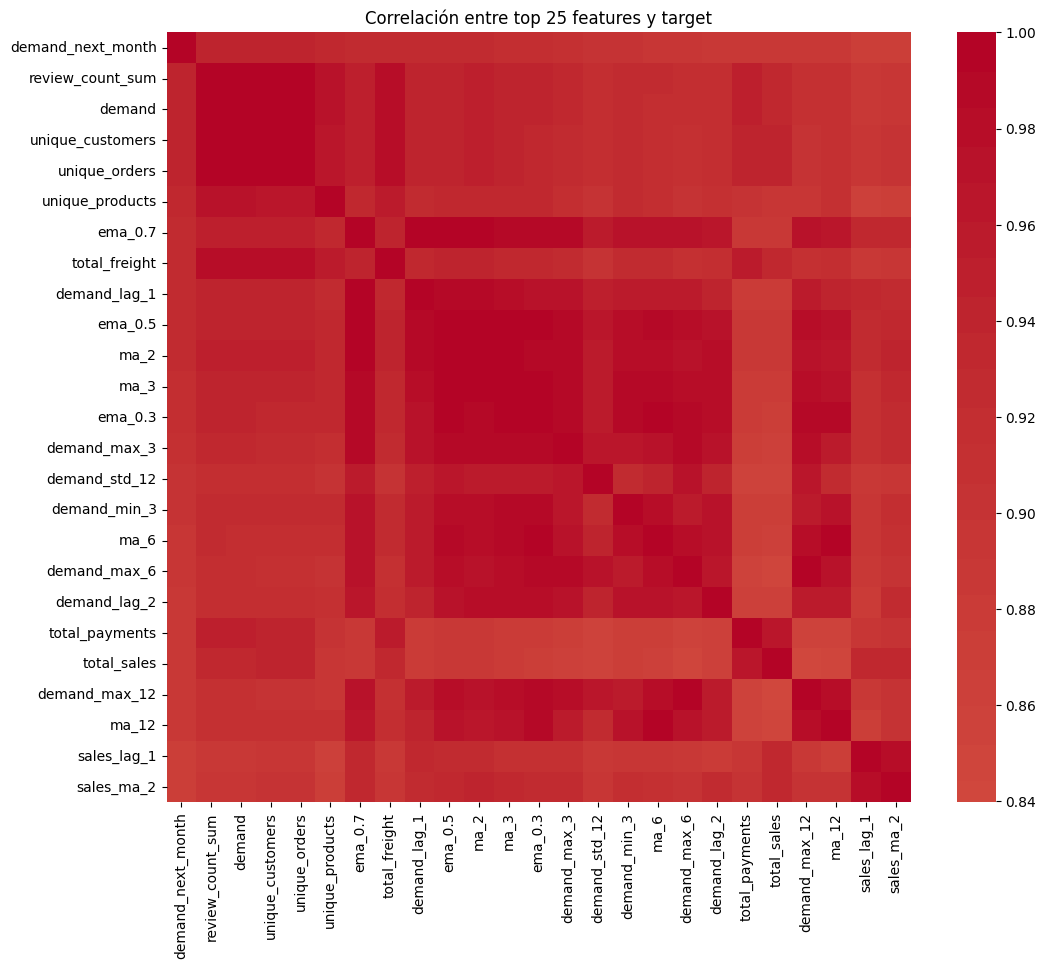

In [9]:
# Celda 5c: heatmap de las 25 features más correlacionadas con la target

top_n = 25
top_features = corr_abs.head(top_n).index.tolist()

plt.figure(figsize=(12,10))
sns.heatmap(num_df[top_features].corr(), annot=False, cmap="coolwarm", center=0)
plt.title(f"Correlación entre top {top_n} features y target")
plt.show()


In [10]:
# Celda 6: eliminar multicolinealidad de las features numéricas

# Empezamos con todas las numéricas excepto la target
X_all = num_df.drop(columns=[TARGET]).copy()

# Matriz de correlación absoluta
corr_matrix = X_all.corr().abs()

# Usamos solo triángulo superior para evitar duplicados
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Listado de columnas a eliminar por correlación alta
threshold = 0.90
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

len(to_drop), to_drop[:20]


(71,
 ['unique_products',
  'unique_orders',
  'unique_customers',
  'unique_sellers',
  'total_sales',
  'total_freight',
  'total_payments',
  'payment_avg_mean',
  'review_count_sum',
  'pct_boleto_mean',
  'quarter',
  'demand_lag_1',
  'sales_lag_1',
  'demand_lag_2',
  'sales_lag_2',
  'demand_lag_3',
  'sales_lag_3',
  'sales_lag_6',
  'sales_lag_12',
  'ma_2'])

In [11]:
# Celda 6b: construir X_reduced sin las features súper correlacionadas

X_reduced = X_all.drop(columns=to_drop, errors="ignore").copy()

print("Shape original de X_all:", X_all.shape)
print("Shape reducido de X_reduced:", X_reduced.shape)


Shape original de X_all: (1195, 170)
Shape reducido de X_reduced: (1195, 99)


In [12]:
# Celda 7: SelectKBest para ranking adicional de features

# Aseguramos alineación
X_for_kbest = X_reduced.copy()
y_for_kbest = num_df[TARGET].copy()

n_features = X_for_kbest.shape[1]
k = min(50, n_features)  # máximo 50

selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_for_kbest, y_for_kbest)

selected_mask = selector.get_support()
selected_features_kbest = X_for_kbest.columns[selected_mask]

print("Número de features seleccionadas por KBest:", len(selected_features_kbest))
selected_features_kbest[:30]


Número de features seleccionadas por KBest: 50


Index(['demand', 'avg_price', 'price_min', 'price_max', 'avg_freight',
       'avg_payment', 'delivery_time_days_std', 'avg_delivery_delay', 'year',
       'is_december', 'price_lag_1', 'review_lag_1', 'delivery_lag_1',
       'review_lag_2', 'delivery_lag_2', 'review_lag_3', 'delivery_lag_3',
       'demand_lag_6', 'review_lag_6', 'delivery_lag_6', 'demand_lag_12',
       'price_lag_12', 'review_lag_12', 'delivery_lag_12', 'demand_std_3',
       'price_std_3', 'price_std_6', 'demand_growth_1m', 'demand_growth_12m',
       'sales_growth_1m'],
      dtype='object')

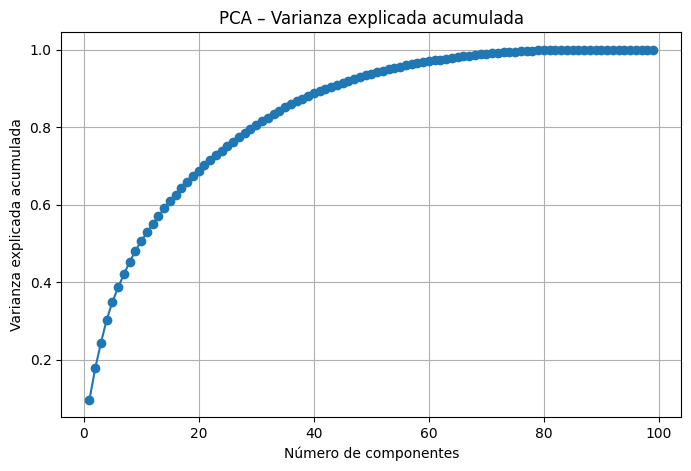

In [13]:
# Celda 8: PCA exploratorio

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

pca = PCA().fit(X_scaled)
var_explicada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_explicada)+1), var_explicada, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA – Varianza explicada acumulada")
plt.grid(True)
plt.show()


In [14]:
# Celda 2: Confirmación de las 99 features finales

TARGET = "demand_next_month"

# Todas las numéricas menos la target
X_all = df.select_dtypes(include=[np.number]).drop(columns=[TARGET], errors="ignore")

# Matriz de correlación absoluta
corr_matrix = X_all.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Features con correlación > 0.90 (las eliminamos)
threshold = 0.90
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

len(to_drop), to_drop[:10]


(71,
 ['unique_products',
  'unique_orders',
  'unique_customers',
  'unique_sellers',
  'total_sales',
  'total_freight',
  'total_payments',
  'payment_avg_mean',
  'review_count_sum',
  'pct_boleto_mean'])

In [15]:
# Celda 3: lista final de 99 features para modelado

X_reduced = X_all.drop(columns=to_drop, errors="ignore")

FEATURE_SET = X_reduced.columns.tolist()

print("Número final de features:", len(FEATURE_SET))
FEATURE_SET[:20]

Número final de features: 99


['demand',
 'avg_price',
 'price_std',
 'price_min',
 'price_max',
 'avg_freight',
 'avg_payment',
 'payment_count_mean',
 'installments_avg_mean',
 'avg_review_score',
 'avg_delivery_time_days',
 'delivery_time_days_std',
 'avg_delivery_delay',
 'pct_delayed_orders',
 'pct_credit_card_mean',
 'pct_voucher_mean',
 'pct_debit_card_mean',
 'review_pct_1_mean',
 'review_pct_2_mean',
 'review_pct_3_mean']

In [16]:
# Celda 4: Construcción de X y y para modelado

num_df = df.select_dtypes(include=[np.number]).copy()

X = num_df[FEATURE_SET].copy()
y = num_df[TARGET].copy()

print(X.shape, y.shape)


(1195, 99) (1195,)


In [17]:
# ------------------------------------------------------------
# Split temporal:
# Train:     hasta 2018-04
# Backtest:  2018-05 y 2018-06
# Test:      2018-07 (último mes con target válida)
# ------------------------------------------------------------

df_sorted = df.sort_values('order_month').copy()
periods = df_sorted['order_month'].dt.to_period('M')

train_end    = pd.Period('2018-04')
back_periods = [pd.Period('2018-05'), pd.Period('2018-06')]
test_period  = pd.Period('2018-07')

train_mask = periods <= train_end
back_mask  = periods.isin(back_periods)
test_mask  = periods == test_period

# Reordenamos X e y según el mismo índice de df_sorted
X_sorted = X.loc[df_sorted.index]
y_sorted = y.loc[df_sorted.index]

X_train, y_train = X_sorted[train_mask], y_sorted[train_mask]
X_back,  y_back  = X_sorted[back_mask],  y_sorted[back_mask]
X_test,  y_test  = X_sorted[test_mask],  y_sorted[test_mask]

print("Train :", X_train.shape)
print("Back  :", X_back.shape)
print("Test  :", X_test.shape)

print("\nPeriodos únicos por split:")
print("Train meses   :", np.sort(periods[train_mask].unique()))
print("Back meses    :", np.sort(periods[back_mask].unique()))
print("Test mes      :", np.sort(periods[test_mask].unique()))



Train : (1003, 99)
Back  : (128, 99)
Test  : (64, 99)

Periodos únicos por split:
Train meses   : [Period('2016-10', 'M') Period('2016-12', 'M') Period('2017-01', 'M')
 Period('2017-02', 'M') Period('2017-03', 'M') Period('2017-04', 'M')
 Period('2017-05', 'M') Period('2017-06', 'M') Period('2017-07', 'M')
 Period('2017-08', 'M') Period('2017-09', 'M') Period('2017-10', 'M')
 Period('2017-11', 'M') Period('2017-12', 'M') Period('2018-01', 'M')
 Period('2018-02', 'M') Period('2018-03', 'M') Period('2018-04', 'M')]
Back meses    : [Period('2018-05', 'M') Period('2018-06', 'M')]
Test mes      : [Period('2018-07', 'M')]


In [27]:
# ================================
# Funciones de métricas + Naive
# ================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- MAPE ---
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0  # evitamos división por cero
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# --- Evaluar modelo en train / backtest / test ---
def evaluar_modelo(nombre, y_train, y_train_pred,
                   y_back,  y_back_pred,
                   y_test,  y_test_pred):

    # RMSE = sqrt(MSE)  (sin usar el parámetro squared)
    rmse_train = mean_squared_error(y_train, y_train_pred) ** 0.5
    rmse_back  = mean_squared_error(y_back,  y_back_pred)  ** 0.5
    rmse_test  = mean_squared_error(y_test,  y_test_pred)  ** 0.5

    resultados = {
        'modelo': nombre,

        'MAPE_train': mape(y_train, y_train_pred),
        'MAE_train': mean_absolute_error(y_train, y_train_pred),
        'RMSE_train': rmse_train,
        'R2_train': r2_score(y_train, y_train_pred),

        'MAPE_back': mape(y_back, y_back_pred),
        'MAE_back': mean_absolute_error(y_back, y_back_pred),
        'RMSE_back': rmse_back,
        'R2_back': r2_score(y_back, y_back_pred),

        'MAPE_test': mape(y_test, y_test_pred),
        'MAE_test': mean_absolute_error(y_test, y_test_pred),
        'RMSE_test': rmse_test,
        'R2_test': r2_score(y_test, y_test_pred),
    }
    return resultados

In [28]:
# ================================
# Baseline Naive: ŷ = demand_t
# (usa la demanda del mes actual)
# ================================

# Asegúrate de que 'demand' esté en X_train / X_back / X_test
assert 'demand' in X_train.columns, "La columna 'demand' no está en X_train"

y_train_pred_naive = X_train['demand'].values
y_back_pred_naive  = X_back['demand'].values
y_test_pred_naive  = X_test['demand'].values

res_naive = evaluar_modelo(
    'Naive (demand_t)',
    y_train, y_train_pred_naive,
    y_back,  y_back_pred_naive,
    y_test,  y_test_pred_naive
)

import pandas as pd
pd.DataFrame([res_naive])


,modelo,MAPE_train,MAE_train,RMSE_train,R2_train,MAPE_back,MAE_back,RMSE_back,R2_back,MAPE_test,MAE_test,RMSE_test,R2_test
0,Naive (demand_t),51.2336,24.0867,53.3607,0.8696,41.5117,19.5000,39.5293,0.9431,37.7821,20.4219,33.7613,0.9621


In [29]:
# ------------------------------------------------------------
# MODELO 1: Regresión Lineal (benchmark)
# ------------------------------------------------------------

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_train_pred_lr = linreg.predict(X_train)
y_back_pred_lr  = linreg.predict(X_back)
y_test_pred_lr  = linreg.predict(X_test)

res_lr = evaluar_modelo(
    'LinearRegression',
    y_train, y_train_pred_lr,
    y_back, y_back_pred_lr,
    y_test, y_test_pred_lr
)

resultados_modelos.append(res_lr)

pd.DataFrame([res_lr])


,modelo,MAPE_train,MAE_train,RMSE_train,R2_train,MAPE_back,MAE_back,RMSE_back,R2_back,MAPE_test,MAE_test,RMSE_test,R2_test
0,LinearRegression,193.5778,23.1354,41.5718,0.9209,138.8721,29.2200,44.7305,0.9271,216.8750,27.5058,39.6317,0.9478


In [30]:
# ------------------------------------------------------------
# MODELO 2: RandomForest base (sin tuning)
# ------------------------------------------------------------

rf_base = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_train_pred_rf_base = rf_base.predict(X_train)
y_back_pred_rf_base  = rf_base.predict(X_back)
y_test_pred_rf_base  = rf_base.predict(X_test)

res_rf_base = evaluar_modelo(
    'RandomForest_base',
    y_train, y_train_pred_rf_base,
    y_back, y_back_pred_rf_base,
    y_test, y_test_pred_rf_base
)

resultados_modelos.append(res_rf_base)

pd.DataFrame([res_rf_base])


,modelo,MAPE_train,MAE_train,RMSE_train,R2_train,MAPE_back,MAE_back,RMSE_back,R2_back,MAPE_test,MAE_test,RMSE_test,R2_test
0,RandomForest_base,25.6070,7.6830,16.9082,0.9869,51.0708,28.4620,50.3062,0.9078,52.7796,22.7039,43.5683,0.9369


In [42]:
# ------------------------------------------------------------
# MODELO 3: RandomForest tunado (RandomizedSearchCV)
# ------------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=3)

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_distributions,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Mejores hiperparámetros RF:", rf_search.best_params_)

best_rf = rf_search.best_estimator_

y_train_pred_rf = best_rf.predict(X_train)
y_back_pred_rf  = best_rf.predict(X_back)
y_test_pred_rf  = best_rf.predict(X_test)

res_rf = evaluar_modelo(
    'RandomForest_tunado',
    y_train, y_train_pred_rf,
    y_back, y_back_pred_rf,
    y_test, y_test_pred_rf
)

resultados_modelos.append(res_rf)

pd.DataFrame([res_rf])


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores hiperparámetros RF: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 15}


,modelo,MAPE_train,MAE_train,RMSE_train,R2_train,MAPE_back,MAE_back,RMSE_back,R2_back,MAPE_test,MAE_test,RMSE_test,R2_test
0,RandomForest_tunado,30.7645,8.6807,20.1244,0.9815,50.9859,28.6412,50.3006,0.9078,52.1880,23.1996,44.5870,0.9339


In [43]:
# ------------------------------------------------------------
# MODELO 4: XGBoost base (sin tuning pesado)
# ------------------------------------------------------------

# ===========================================
# Verificar si XGBoost está disponible
# ===========================================
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("✔ XGBoost disponible")
except:
    XGB_AVAILABLE = False
    print("✖ XGBoost NO está disponible")

if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    y_train_pred_xgb = xgb_model.predict(X_train)
    y_back_pred_xgb  = xgb_model.predict(X_back)
    y_test_pred_xgb  = xgb_model.predict(X_test)

    res_xgb = evaluar_modelo(
        'XGBoost_base',
        y_train, y_train_pred_xgb,
        y_back, y_back_pred_xgb,
        y_test, y_test_pred_xgb
    )

    resultados_modelos.append(res_xgb)

    pd.DataFrame([res_xgb])
else:
    print("XGBoost no disponible; omitiendo este modelo.")


✔ XGBoost disponible


In [44]:
# ------------------------------------------------------------
# COMPARACIÓN FINAL DE MODELOS
# ------------------------------------------------------------

resultados_df = pd.DataFrame(resultados_modelos)
resultados_df = resultados_df.sort_values('MAPE_test')
resultados_df


,modelo,MAPE_train,MAE_train,RMSE_train,R2_train,MAPE_back,MAE_back,RMSE_back,R2_back,MAPE_test,MAE_test,RMSE_test,R2_test
2,RandomForest_tunado,30.7645,8.6807,20.1244,0.9815,50.9859,28.6412,50.3006,0.9078,52.1880,23.1996,44.5870,0.9339
5,RandomForest_tunado,30.7645,8.6807,20.1244,0.9815,50.9859,28.6412,50.3006,0.9078,52.1880,23.1996,44.5870,0.9339
1,RandomForest_base,25.6070,7.6830,16.9082,0.9869,51.0708,28.4620,50.3062,0.9078,52.7796,22.7039,43.5683,0.9369
3,XGBoost_base,32.0279,2.9923,4.0023,0.9993,47.2770,24.5648,47.1115,0.9191,61.8345,23.1902,44.7342,0.9335
6,XGBoost_base,32.0279,2.9923,4.0023,0.9993,47.2770,24.5648,47.1115,0.9191,61.8345,23.1902,44.7342,0.9335
4,XGBoost_tunado,48.5696,5.7816,8.1451,0.9970,58.9319,27.5672,47.5575,0.9176,68.5270,25.6030,45.2046,0.9321
0,LinearRegression,193.5778,23.1354,41.5718,0.9209,138.8721,29.2200,44.7305,0.9271,216.8750,27.5058,39.6317,0.9478


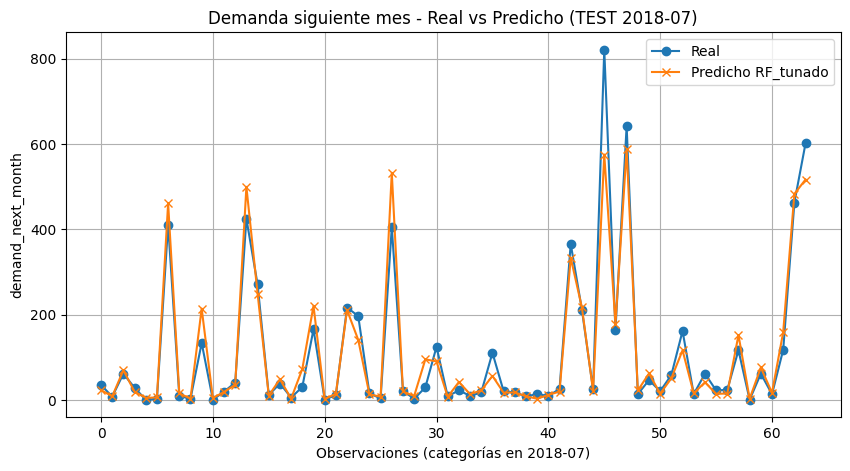

In [45]:
# ------------------------------------------------------------
# GRÁFICO: Real vs Predicho en TEST (RandomForest_tunado)
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Real', marker='o')
plt.plot(y_test_pred_rf, label='Predicho RF_tunado', marker='x')
plt.title('Demanda siguiente mes - Real vs Predicho (TEST 2018-07)')
plt.xlabel('Observaciones (categorías en 2018-07)')
plt.ylabel('demand_next_month')
plt.legend()
plt.grid(True)
plt.show()


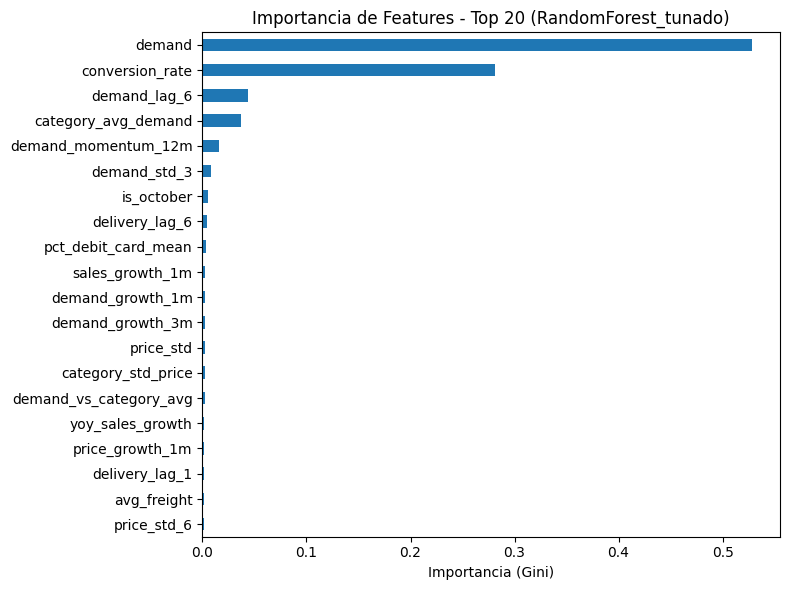

,0
demand,0.5288
conversion_rate,0.2808
demand_lag_6,0.0437
category_avg_demand,0.0371
demand_momentum_12m,0.0158
demand_std_3,0.0086
is_october,0.0055
delivery_lag_6,0.0039
pct_debit_card_mean,0.0039
sales_growth_1m,0.0027


In [46]:
# ------------------------------------------------------------
# FEATURE IMPORTANCE (RandomForest_tunado) - Top 20
# ------------------------------------------------------------

importancias = pd.Series(best_rf.feature_importances_, index=FEATURE_SET)
importancias_top20 = importancias.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
importancias_top20.sort_values().plot(kind='barh')
plt.title('Importancia de Features - Top 20 (RandomForest_tunado)')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

importancias_top20


In [47]:
# ------------------------------------------------------------
# EXPORTAR MODELO FINAL Y FEATURE_SET
# ------------------------------------------------------------

model_path = '/content/drive/MyDrive/modelo_final_sprint3.pkl'
features_path = '/content/drive/MyDrive/feature_set_sprint3.pkl'

joblib.dump(best_rf, model_path)
joblib.dump(FEATURE_SET, features_path)

print("Modelo final guardado en:", model_path)
print("Feature set guardado en:", features_path)


Modelo final guardado en: /content/drive/MyDrive/modelo_final_sprint3.pkl
Feature set guardado en: /content/drive/MyDrive/feature_set_sprint3.pkl


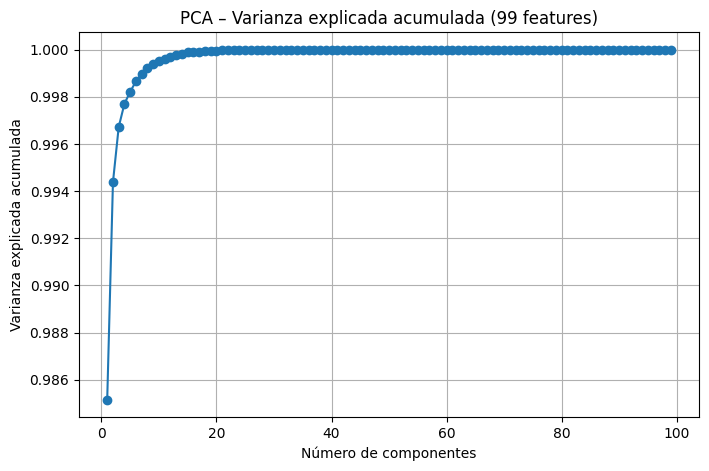

Varianza explicada con 10, 20, 30, 50 comps:
10 componentes → 99.95%
20 componentes → 100.00%
30 componentes → 100.00%
50 componentes → 100.00%


In [48]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# X_reduced = tus 99 features numéricas (por ejemplo: X)
X_pca = X.values  # matriz (n_muestras, 99)

pca = PCA(n_components=X_pca.shape[1])
pca.fit(X_pca)

var_expl = pca.explained_variance_ratio_
var_acum = np.cumsum(var_expl)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum)+1), var_acum, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA – Varianza explicada acumulada (99 features)')
plt.grid(True)
plt.show()

print("Varianza explicada con 10, 20, 30, 50 comps:")
for k in [10, 20, 30, 50]:
    print(f"{k} componentes → {var_acum[k-1]*100:.2f}%")


In [39]:
!pip install boruta

from boruta import BorutaPy
from sklearn.ensemble import RandomForestRegressor

# Usamos un RF relativamente pequeño para que no tarde tanto
rf_boruta = RandomForestRegressor(
    n_estimators=500,
    max_depth=7,
    n_jobs=-1,
    random_state=42
)

boruta_selector = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    max_iter=50,
    random_state=42
)

print("Ejecutando Boruta... puede tardar un rato.")
boruta_selector.fit(X.values, y.values)

# Máscaras de selección
support = boruta_selector.support_
ranking = boruta_selector.ranking_

boruta_features = [feat for feat, keep in zip(FEATURE_SET, support) if keep]

print(f"Features aceptadas por Boruta: {len(boruta_features)}")
print("Primeras 20:", boruta_features[:20])

# Guardar lista de features aceptadas
import pandas as pd
pd.DataFrame(boruta_features, columns=['feature']).to_csv(
    '/content/drive/MyDrive/FEATURES_BORUTA.csv', index=False
)

print("✔ FEATURES_BORUTA.csv guardado en Drive")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 1.8 MB/s eta 0:00:00
Ejecutando Boruta... puede tardar un rato.
Features aceptadas por Boruta: 6
Primeras 20: ['demand', 'is_october', 'demand_growth_1m', 'demand_momentum_12m', 'conversion_rate', 'category_avg_demand']
✔ FEATURES_BORUTA.csv guardado en Drive


In [49]:
# ============================================================
# XGBoost + CatBoost: instalación e imports
# ============================================================

!pip install xgboost catboost -q

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Flags para saber si están disponibles
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("✔ XGBoost disponible")
except Exception as e:
    XGB_AVAILABLE = False
    print("✖ XGBoost NO disponible:", e)

try:
    from catboost import CatBoostRegressor
    CAT_AVAILABLE = True
    print("✔ CatBoost disponible")
except Exception as e:
    CAT_AVAILABLE = False
    print("✖ CatBoost NO disponible:", e)

# Aseguramos que exista la lista de resultados
if 'resultados_modelos' not in globals():
    resultados_modelos = []

# Validación temporal
tscv = TimeSeriesSplit(n_splits=3)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.7 MB/s eta 0:00:00
✔ XGBoost disponible
✔ CatBoost disponible


In [50]:
# ============================================================
# MODELO 1: XGBoost tunado (RandomizedSearchCV + TimeSeriesSplit)
# ============================================================

if XGB_AVAILABLE:
    xgb_base = xgb.XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',   # rápido en CPU
        random_state=42,
        n_jobs=-1
    )

    param_dist_xgb = {
        'n_estimators':    [300, 400, 500, 700],
        'max_depth':       [3, 4, 5, 6, 8],
        'learning_rate':   [0.01, 0.03, 0.05, 0.1],
        'subsample':       [0.6, 0.8, 1.0],
        'colsample_bytree':[0.6, 0.8, 1.0],
        'min_child_weight':[1, 3, 5, 7]
    }

    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_dist_xgb,
        n_iter=30,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    print("⏳ Buscando mejores hiperparámetros para XGBoost...")
    xgb_search.fit(X_train, y_train)

    print("Mejores parámetros XGBoost:", xgb_search.best_params_)

    best_xgb = xgb_search.best_estimator_

    # Predicciones
    y_train_pred_xgb = best_xgb.predict(X_train)
    y_back_pred_xgb  = best_xgb.predict(X_back)
    y_test_pred_xgb  = best_xgb.predict(X_test)

    res_xgb = evaluar_modelo(
        'XGBoost_tunado',
        y_train, y_train_pred_xgb,
        y_back,  y_back_pred_xgb,
        y_test,  y_test_pred_xgb
    )

    resultados_modelos.append(res_xgb)
    display(pd.DataFrame([res_xgb]))
else:
    print("XGBoost no disponible; se omite este modelo.")



# ============================================================
# MODELO 2: CatBoost tunado (búsqueda ligera)
# ============================================================

if CAT_AVAILABLE:
    # CatBoost maneja bien muchas features y overfitting,
    # hacemos un tuning ligero
    cat_base = CatBoostRegressor(
        loss_function='RMSE',
        random_state=42,
        verbose=0
    )

    param_dist_cat = {
        'depth':        [4, 5, 6, 8, 10],
        'learning_rate':[0.01, 0.03, 0.05, 0.1],
        'l2_leaf_reg':  [1, 3, 5, 7, 9],
        'iterations':   [300, 500, 700, 900]
    }

    cat_search = RandomizedSearchCV(
        estimator=cat_base,
        param_distributions=param_dist_cat,
        n_iter=25,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    print("⏳ Buscando mejores hiperparámetros para CatBoost...")
    cat_search.fit(X_train, y_train)

    print("Mejores parámetros CatBoost:", cat_search.best_params_)

    best_cat = cat_search.best_estimator_

    # Predicciones
    y_train_pred_cat = best_cat.predict(X_train)
    y_back_pred_cat  = best_cat.predict(X_back)
    y_test_pred_cat  = best_cat.predict(X_test)

    res_cat = evaluar_modelo(
        'CatBoost_tunado',
        y_train, y_train_pred_cat,
        y_back,  y_back_pred_cat,
        y_test,  y_test_pred_cat
    )

    resultados_modelos.append(res_cat)
    display(pd.DataFrame([res_cat]))
else:
    print("CatBoost no disponible; se omite este modelo.")



# ============================================================
# TABLA FINAL DE MODELOS (incluye Naive, RF, XGB, CatBoost, etc.)
# ============================================================

resultados_df = pd.DataFrame(resultados_modelos)
resultados_df = resultados_df.sort_values('MAPE_test')
display(resultados_df)


⏳ Buscando mejores hiperparámetros para XGBoost...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores parámetros XGBoost: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


,modelo,MAPE_train,MAE_train,RMSE_train,R2_train,MAPE_back,MAE_back,RMSE_back,R2_back,MAPE_test,MAE_test,RMSE_test,R2_test
0,XGBoost_tunado,48.5696,5.7816,8.1451,0.9970,58.9319,27.5672,47.5575,0.9176,68.5270,25.6030,45.2046,0.9321


⏳ Buscando mejores hiperparámetros para CatBoost...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Mejores parámetros CatBoost: {'learning_rate': 0.03, 'l2_leaf_reg': 9, 'iterations': 900, 'depth': 4}


,modelo,MAPE_train,MAE_train,RMSE_train,R2_train,MAPE_back,MAE_back,RMSE_back,R2_back,MAPE_test,MAE_test,RMSE_test,R2_test
0,CatBoost_tunado,68.8769,10.7213,17.0931,0.9866,66.1023,26.0359,47.4069,0.9181,86.6872,27.1300,50.5278,0.9151


,modelo,MAPE_train,MAE_train,RMSE_train,R2_train,MAPE_back,MAE_back,RMSE_back,R2_back,MAPE_test,MAE_test,RMSE_test,R2_test
2,RandomForest_tunado,30.7645,8.6807,20.1244,0.9815,50.9859,28.6412,50.3006,0.9078,52.1880,23.1996,44.5870,0.9339
5,RandomForest_tunado,30.7645,8.6807,20.1244,0.9815,50.9859,28.6412,50.3006,0.9078,52.1880,23.1996,44.5870,0.9339
1,RandomForest_base,25.6070,7.6830,16.9082,0.9869,51.0708,28.4620,50.3062,0.9078,52.7796,22.7039,43.5683,0.9369
3,XGBoost_base,32.0279,2.9923,4.0023,0.9993,47.2770,24.5648,47.1115,0.9191,61.8345,23.1902,44.7342,0.9335
6,XGBoost_base,32.0279,2.9923,4.0023,0.9993,47.2770,24.5648,47.1115,0.9191,61.8345,23.1902,44.7342,0.9335
4,XGBoost_tunado,48.5696,5.7816,8.1451,0.9970,58.9319,27.5672,47.5575,0.9176,68.5270,25.6030,45.2046,0.9321
7,XGBoost_tunado,48.5696,5.7816,8.1451,0.9970,58.9319,27.5672,47.5575,0.9176,68.5270,25.6030,45.2046,0.9321
8,CatBoost_tunado,68.8769,10.7213,17.0931,0.9866,66.1023,26.0359,47.4069,0.9181,86.6872,27.1300,50.5278,0.9151
0,LinearRegression,193.5778,23.1354,41.5718,0.9209,138.8721,29.2200,44.7305,0.9271,216.8750,27.5058,39.6317,0.9478
